In [36]:
from pyprojroot import here
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

PERMANENT_PALETTE = {'1JK9': '#70A8CE', '1KXP': '#FFB26E', '1US7': '#88C588', '1Z5Y': '#E67D7E', '1ZHH': '#BDA3D6', '1ZHI': '#BA9993', '2A5T': '#EEADDA', '2AJF': '#B7D3E6', '2C0L': '#FFD8B6', '2GAF': '#C3E2C3', '2YVJ': '#F2BEBE', '3PC8': '#DED1EA', '4H03': '#DCCCC9'}
print(Path(here()))

### In the future caprieval data must be loaded from a single file
fp_small = here() / 'metadata/haddock3_all_caprievals.tsv'
fp_old = here() / 'metadata/all_caprievals_unrestrained_10k.tsv'

df_small = pd.read_csv(fp_small, sep="\t")

df_old = pd.read_csv(fp_old, sep="\t")
df_old['run_type'] = 'abinitio_1000_100_flex'
df_old['is_flex'] = 'flex'
df_old['docking_approach'] = 'abinitio'

common_columns = df_small.columns.intersection(df_old.columns)

df_capri = pd.concat(
    [df_small[common_columns], df_old[common_columns]], 
    ignore_index=True
)

df_capri.head()

/orfeo/cephfs/scratch/area/ssenci/senci_projects/esm3ppisites_v2/ESM3-PPISites/haddock_eval


,model,md5,caprieval_rank,score,irmsd,fnat,lrmsd,ilrmsd,dockq,rmsd,...,sym,total,vdw,vean,xpcs,complex,run_type,is_flex,docking_approach,score_rank
0,../../4_emref/emref_6.pdb,-,1,-79.311,2.755,0.427,2.650,2.632,0.522,3.433,...,0.0,-252.625,-32.815,0.0,0.0,1JK9,oracle_100_10_flex,flex,oracle,1
1,../../4_emref/emref_9.pdb,-,2,-76.199,2.648,0.519,2.352,2.044,0.563,3.494,...,0.0,-237.660,-32.540,0.0,0.0,1JK9,oracle_100_10_flex,flex,oracle,2
2,../../4_emref/emref_8.pdb,-,3,-67.128,2.762,0.405,2.767,2.705,0.512,3.424,...,0.0,-224.846,-26.417,0.0,0.0,1JK9,oracle_100_10_flex,flex,oracle,3
3,../../4_emref/emref_7.pdb,-,4,-66.941,2.846,0.356,3.263,3.418,0.482,3.480,...,0.0,-225.016,-27.268,0.0,0.0,1JK9,oracle_100_10_flex,flex,oracle,4
4,../../4_emref/emref_10.pdb,-,5,-65.399,2.943,0.459,4.671,4.160,0.478,3.761,...,0.0,-210.092,-26.501,0.0,0.0,1JK9,oracle_100_10_flex,flex,oracle,5


In [37]:
n_top_ranking = 5
topcapri = df_capri[df_capri['score_rank']<=n_top_ranking]
len(topcapri)

172

In [38]:
def plot_irmsd_panel(df: pd.DataFrame, out_png: str) -> None:
    groups = df.groupby(['docking_approach', 'complex'])
    all_ranks = sorted(df['score_rank'].unique())
    rank_to_pos = {r: p for r, p in zip(all_ranks, range(1, len(all_ranks) + 1))}

    n_groups = len(groups)
    nrows = (n_groups + NCOLS - 1) // NCOLS

    fig, axes = plt.subplots(
        nrows, NCOLS,
        figsize=(NCOLS * FIG_WIDTH, nrows * FIG_HEIGHT),
        sharex=True, sharey=True
    )
    axes = axes.flatten() if n_groups > 1 else [axes]

    for ax, ((approach, comp), subdf) in zip(axes, groups):
        subdf = subdf.sort_values('score_rank')
        y = [rank_to_pos[r] for r in subdf['score_rank']]
        color = PERMANENT_PALETTE.get(comp, '#333333')

        ax.barh(y, subdf['irmsd'], color=color, edgecolor='white', height=0.6)
        ax.axvline(x=THRESHOLD, color='darkred', linestyle='--', linewidth=1.2)
        ax.set_yticks(list(rank_to_pos.values()))
        ax.set_yticklabels([str(r) for r in all_ranks])
        ax.set_title(f"{approach}\n{comp}", fontsize=10)
        ax.invert_yaxis()
        ax.set_xlim(left=0)
        ax.grid(axis='x', linestyle=':', alpha=0.5)

    for ax in axes[n_groups:]:
        ax.set_visible(False)

    fig.supxlabel('iRMSD (Å)', fontsize=12)
    fig.supylabel('Score Rank', fontsize=12)
    fig.tight_layout(rect=[0.02, 0.02, 1, 0.98])
    fig.savefig(out_png, dpi=DPI, bbox_inches='tight')
    plt.show()
    plt.close(fig)

1JK9


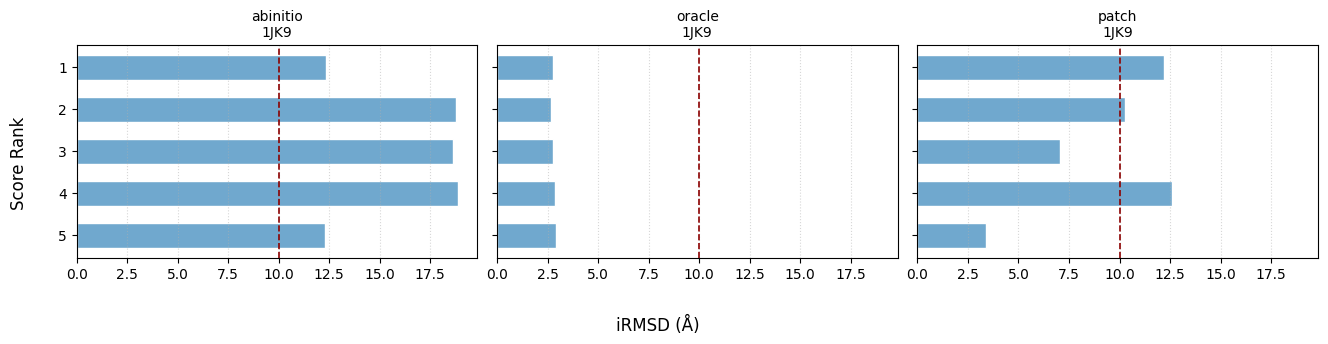

1KXP


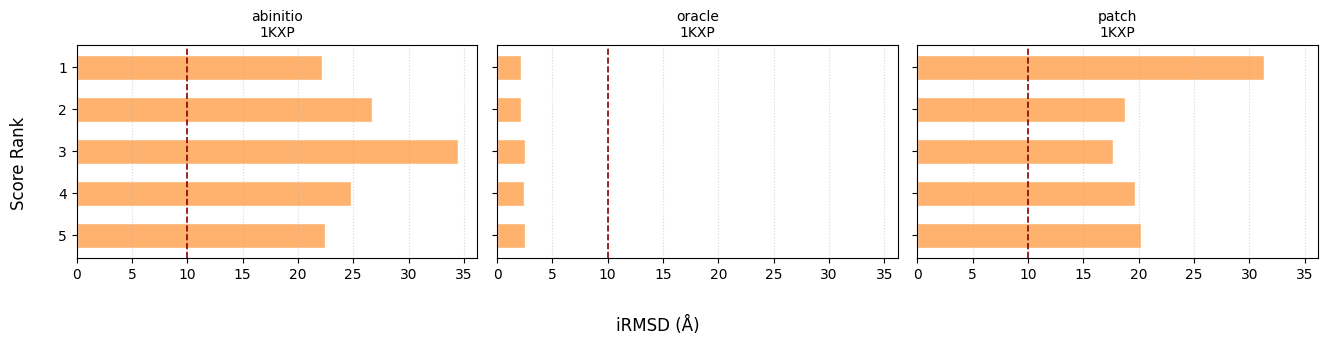

1US7


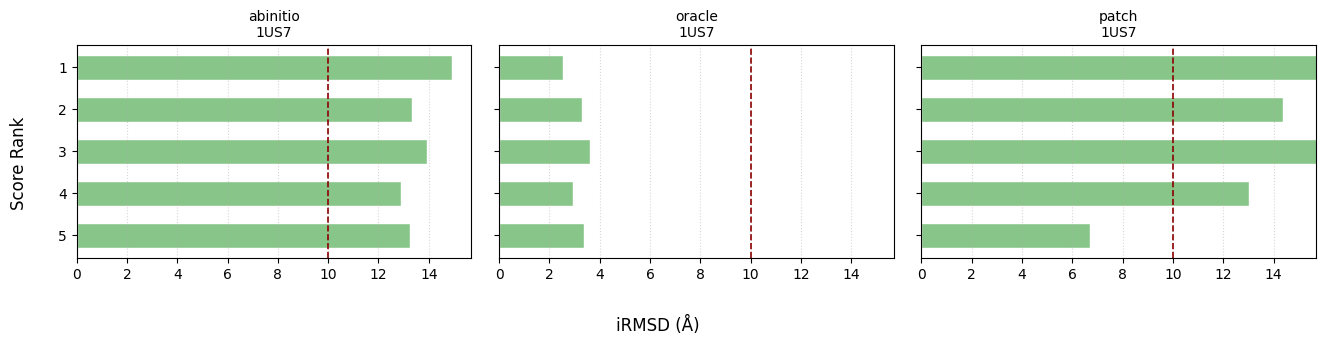

1Z5Y


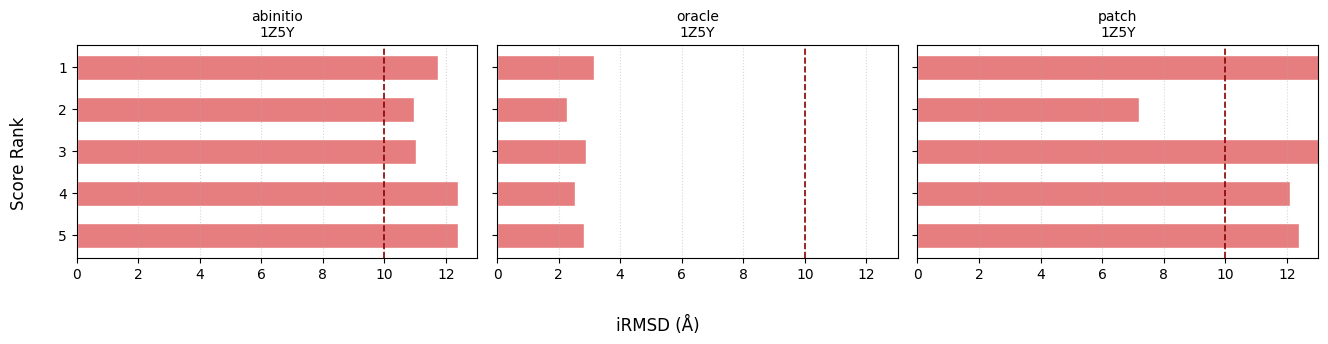

1ZHH


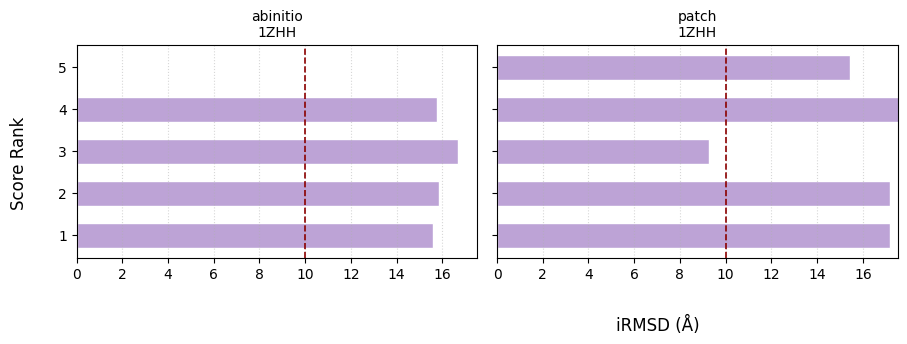

1ZHI


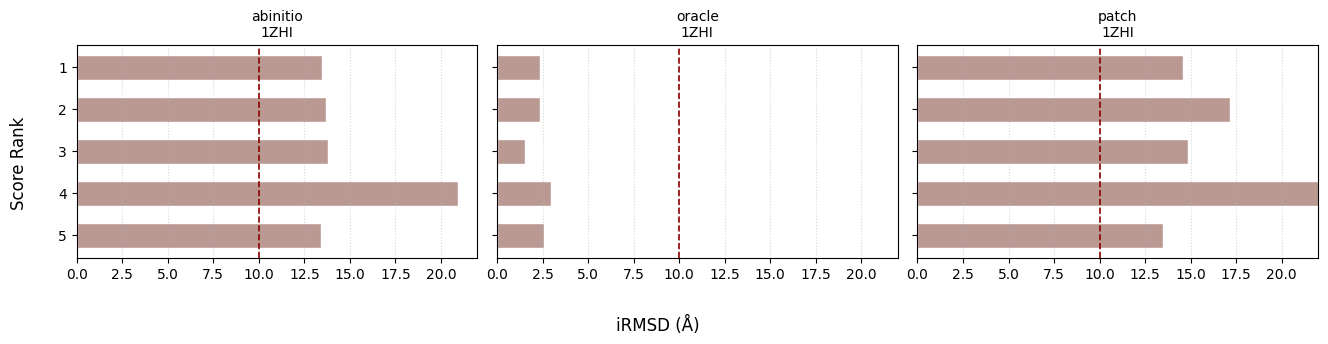

2A5T


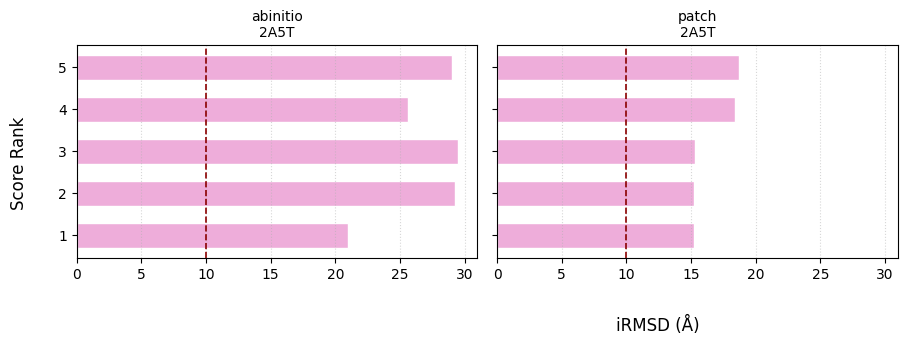

2AJF


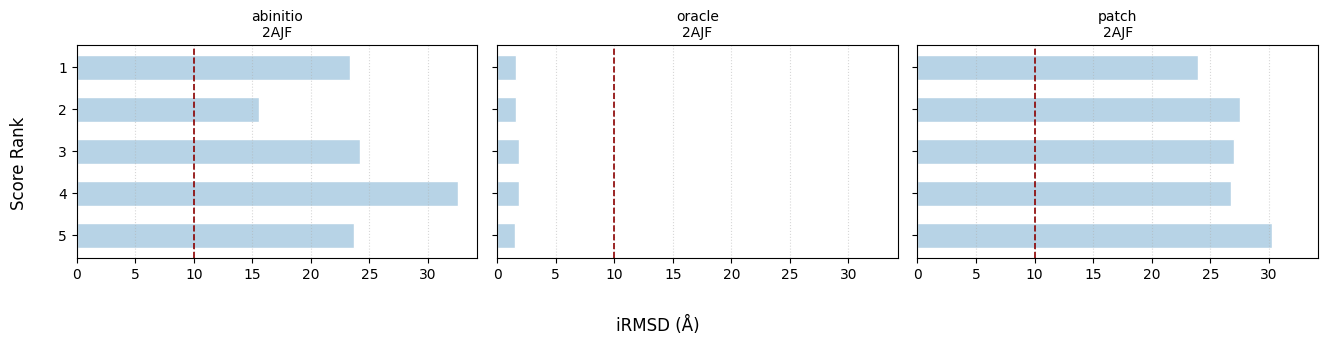

2C0L


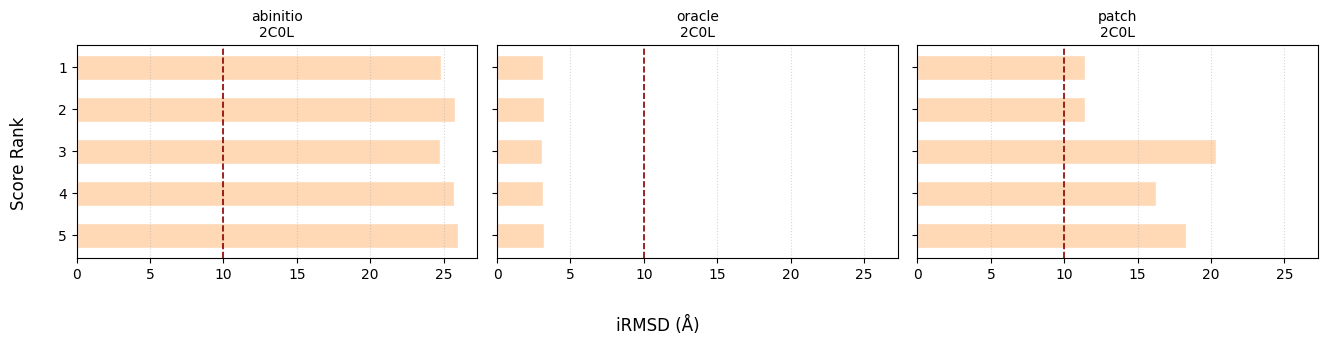

2YVJ


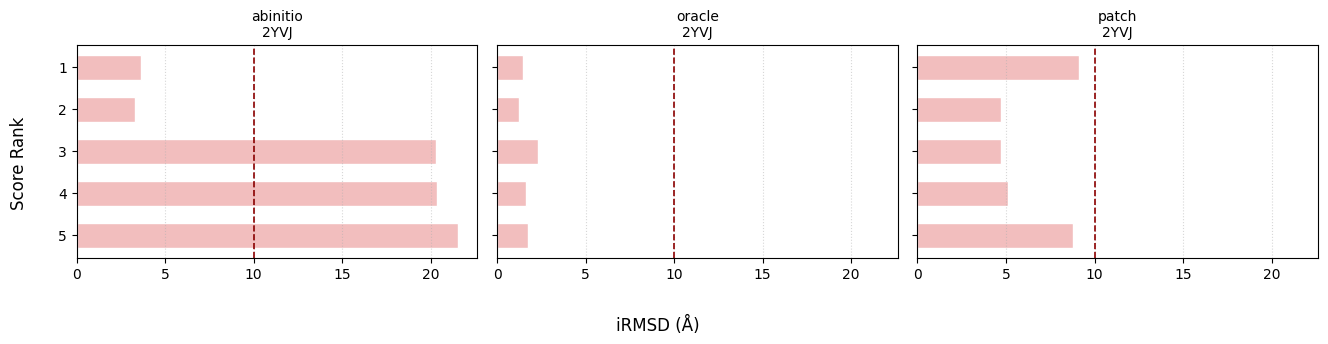

3PC8


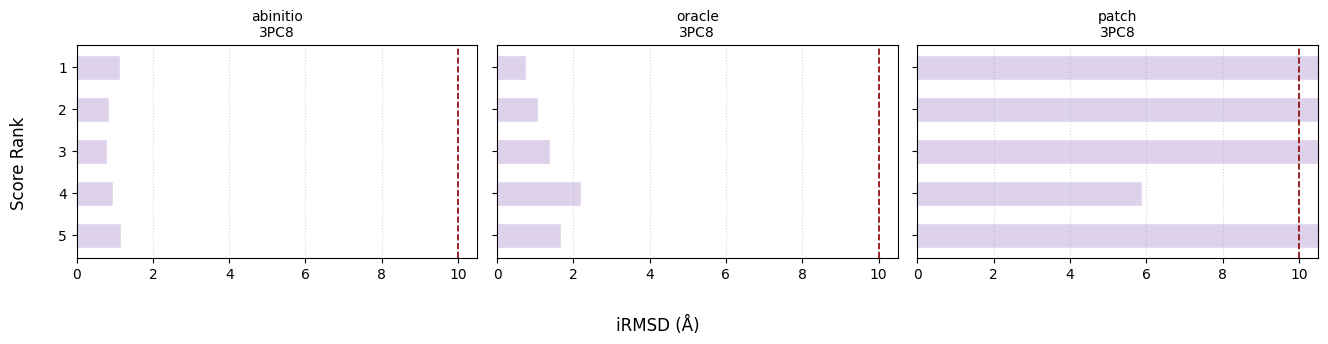

4H03


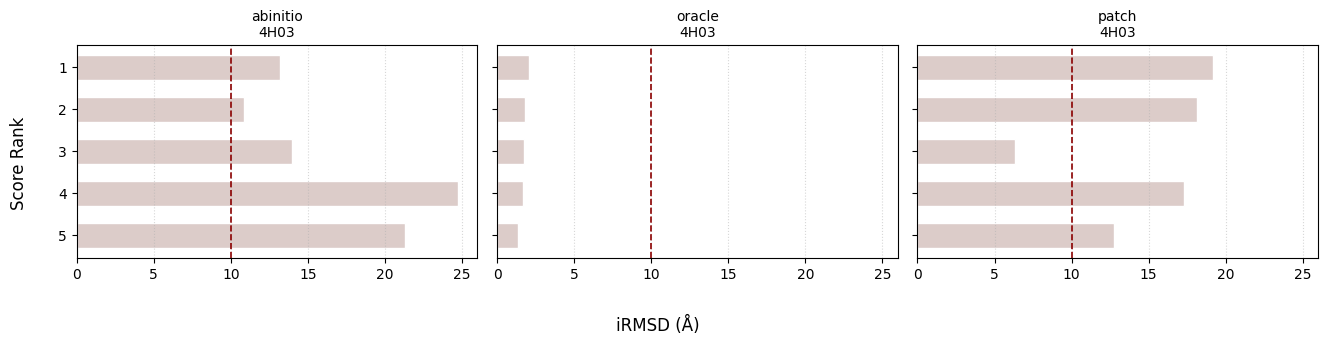

2GAF


AttributeError: 'numpy.ndarray' object has no attribute 'barh'

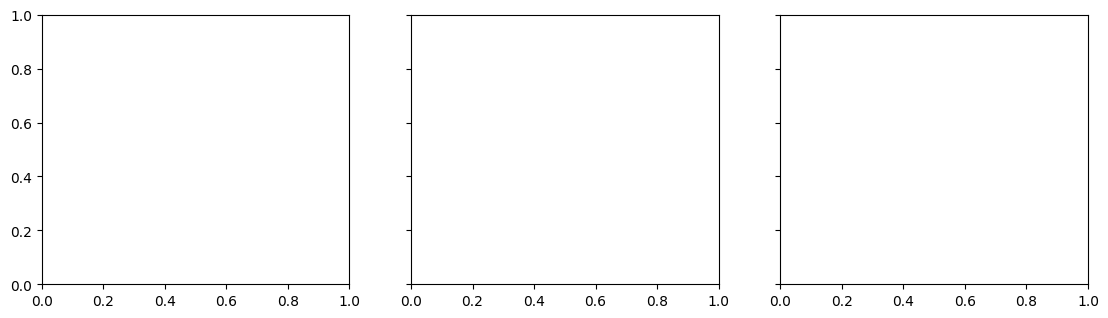

In [40]:
THRESHOLD = 10
NCOLS = 3
FIG_WIDTH = 4.5
FIG_HEIGHT = 3.5
DPI = 200

for complex_name in topcapri['complex'].unique():
    print(complex_name)
    plot_irmsd_panel(topcapri[topcapri['complex']==complex_name], 'cristo.png')